# Files d'attente : simulation Velib

Sarah Daher et Salomé Bellais

## 1. Modélisation

L'objectif est de simuler et d'analyser la probabilité stationnaire qu'une station Vélib soit vide. Le réseau est fermé où les vélos sont les clients circulant entre les stations.

#### Hypothèses :

- Chaque station de vélo peut accepter un nombre infini de vélos.
- Les cyclistes arrivent à une station $j$ selon un processus de Poisson d'intensité $\lambda_j$.
- Si un utilisateur arrive et qu'un vélo est disponible, il le prend immédiatement. Sinon, il repart sans vélo (perte de client).
-  La durée du trajet entre une station $j$ et une station $k$ suit une loi exponentielle de paramètre $\mu_{jk} = 1/t_{jk}$.

Le système ne comporte pas de file d’attente : un usager est servi immédiatement si un vélo est disponible, sinon la demande est perdue.

On décrit l’état du système à un instant donné par la répartition des vélos entre les stations et les trajets. On note :
- $e_i$ : nombre de vélos présents à la station $i$
- $e_{jk}$ : nombre de vélos en trajet de la station $j$ vers la station $k$ (pour $j \neq k$).L’état du système est alors donné par le vecteur :
$$x = (e_i, e_{jk})$$

L’ensemble des états possibles est défini par :$$E = \left\{ (e_i, e_{jk}) ;  e_i \geq 0, e_{jk} \geq 0, \sum_i e_i + \sum_{j \neq k} e_{jk} = N \right\}$$avec $N$  le nombre total de vélos dans le système (système fermé)

On observe 2 types d'événements : les départs depuis les stations et les arrivées aux stations

#### 1. Départ d’un vélo depuis une station
Lorsqu’un usager arrive à la station $i$ :
- Si $e_i > 0$, un vélo est emprunté.
- La destination $k$ est choisie avec la probabilité de routage $p_{ik}$. La transition correspondante est :$$(e_i, e_{ik}) \rightarrow (e_i - 1, e_{ik} + 1)$$Elle se produit avec un taux d'intensité :$$\lambda_i p_{ik} \mathbf{1}_{e_i > 0}$$

#### 2. Arrivée d’un vélo à une station
Un vélo en trajet de $j$ vers $k$ arrive à destination après un temps suivant une loi exponentielle de paramètre $\mu_{jk}$. La transition correspondante est :$$(e_{jk}, e_k) \rightarrow (e_{jk} - 1, e_k + 1)$$Elle se produit avec un taux d'intensité :$$\mu_{jk} e_{jk}$$


## 2. Analyse théorique : cas 1 vélo.  

Nous considérons le cas de N=1 vélo circulant entre les M=5 stations.  
- États du système :
  - Le vélo est à la station $i$ : $e_i = 1$ et tous les autres $e = 0$. On note $\pi_i$ la probabilité de cet état.
  - Le vélo est en trajet de $j$ vers $k$ : $e_{jk} = 1$ et tous les autres $e = 0$. On note $\pi_{jk}$ la probabilité de cet état

D'après les taux de transition définis dans la modélisation :
- Équilibre station-trajet :Pour un trajet de j vers k le vélo y entre depuis la station $j$ avec un taux $\lambda_j p_{jk}$ et en sort avec un taux $\mu_{jk}$. À l'équilibre :$$\pi_j (\lambda_j p_{jk}) = \pi_{jk} \mu_{jk} \implies \pi_{jk} = \frac{\lambda_j p_{jk}}{\mu_{jk}} \pi_j$$
- Équilibre aux stations :Pour une station $i$, le flux sortant (emprunt du vélo) doit etre égal au flux entrant (arrivées de tous les trajets menant à $i$) :$$\pi_i \lambda_i = \sum_{j \neq i} \pi_{ji} \mu_{ji}$$En remplaçant $\pi_{ji}$ par l'expression précédente :$$\pi_i \lambda_i = \sum_{j \neq i} \pi_j \lambda_j p_{ji}$$
On pose $\alpha_i = \pi_i \lambda_i$, donc  $\alpha_i =\sum_{j \neq i} \alpha_j p_{ji}$

 On en déduit les probabilités  :$$\pi_i = \frac{\alpha_i}{\lambda_i} \quad \text{et} \quad \pi_{jk} = \frac{\alpha_j p_{jk}}{\mu_{jk}} = \alpha_j p_{jk} t_{jk}$$


soit $K= \sum_{i=1}^J \frac{\alpha_i}{\lambda_i} + \sum_{j} \sum_{k \neq j} \frac{\alpha_j p_{jk}}{\mu_{jk}}$n la constante de normalisation

La probabilité que la station $i$ soit occupée ($e_i=1$) est $\frac{\alpha_i/\lambda_i}{K}$.

La probabilité que la station $i$ soit vide ($e_i=0$) est donc :

$$\mathbb{P}(e_i = 0) = 1 - \frac{\alpha_i / \lambda_i}{K} = 1 -\frac{\rho_i}{K}$$

## 3. Simulation avec 1 vélo

In [ ]:
import numpy as np

stations_labels = [3, 4, 5, 6, 7]
M = len(stations_labels)

lambdas = np.array([2.8, 3.7, 5.5, 3.5, 4.6])

P = np.array([[0.0, 0.2, 0.3, 0.2, 0.3],[0.2, 0.0, 0.3, 0.2, 0.3],[0.2, 0.25, 0.0, 0.25, 0.3],[0.15, 0.2, 0.3, 0.0, 0.35],[0.2, 0.25, 0.35, 0.2, 0.0]])

T = np.array([[0, 2, 3, 4, 5],[2, 0, 2, 5, 5], [4, 2, 0, 3, 3], [8, 6, 4, 0, 2], [7, 7, 5, 2, 0]  ])
T_heures = T/60. #car lambda en heure

#partie 1 : théorie
#alpha= alpha * P (donc alpha.T est le vecteur propre associé a 1 pour P.T car P.T alpha.T = alpha.T)
eig_vals, eig_vecs = np.linalg.eig(P.T)
alpha = np.real(eig_vecs[:, np.isclose(eig_vals, 1)]).flatten() #on prend le vp le plus (tres) proche de 1 car en python erreurs d'arrondi ...

#calcul de K
poids_stations = np.sum(alpha / lambdas)
poids_trajets = 0
for i in range(M):
    for j in range(M):
        if i != j:
            poids_trajets += alpha[i]*P[i, j]*T_heures[i, j]

K = poids_stations + poids_trajets

#resultat theorique
prob_vide_theo = 1 - (alpha / lambdas) / K

#partie 2 : simulation
n_sauts = 5000000
temps_total = 0
cumul_presence = np.zeros(M)

curr_type = 0 # 0 -> station, 1->trajet
curr_loc = 0 #indice ou tuple si trajet

for _ in range(n_sauts):
    if curr_type == 0:
        #on est dans une station
        taux = lambdas[curr_loc]
        dt = np.random.exponential(1 / taux)

        cumul_presence[curr_loc] += dt
        temps_total += dt

        destination = np.random.choice(M, p=P[curr_loc])
        curr_loc = (curr_loc, destination)
        curr_type = 1
    else:
        # on est dans un trajet
        i, j = curr_loc
        taux_route = 1 / T_heures[i, j]
        dt = np.random.exponential(1 / taux_route)

        temps_total += dt

        curr_loc = j
        curr_type = 0


for i in range(M):
    p_simu_vide = 1 - (cumul_presence[i] / temps_total)
    ecart = abs(prob_vide_theo[i] - p_simu_vide)
    print(f"Station {stations_labels[i]} | {prob_vide_theo[i]:.4f} | {p_simu_vide:.4f} | {ecart:.6f}")

Station 3 | 0.8216 | 0.8215 | 0.000073
Station 4 | 0.8419 | 0.8422 | 0.000324
Station 5 | 0.8632 | 0.8633 | 0.000076
Station 6 | 0.8417 | 0.8416 | 0.000142
Station 7 | 0.8381 | 0.8379 | 0.000127


La simulation réalisée est en accord avec les résultats théoriques

## 4. Simulation avec 100 vélos


Station 3 | Probabilité de vide : 0.0
Station 4 | Probabilité de vide : 0.11740092674948503
Station 5 | Probabilité de vide : 0.2346818446850986
Station 6 | Probabilité de vide : 0.10661413013952536
Station 7 | Probabilité de vide : 0.09608558663709656


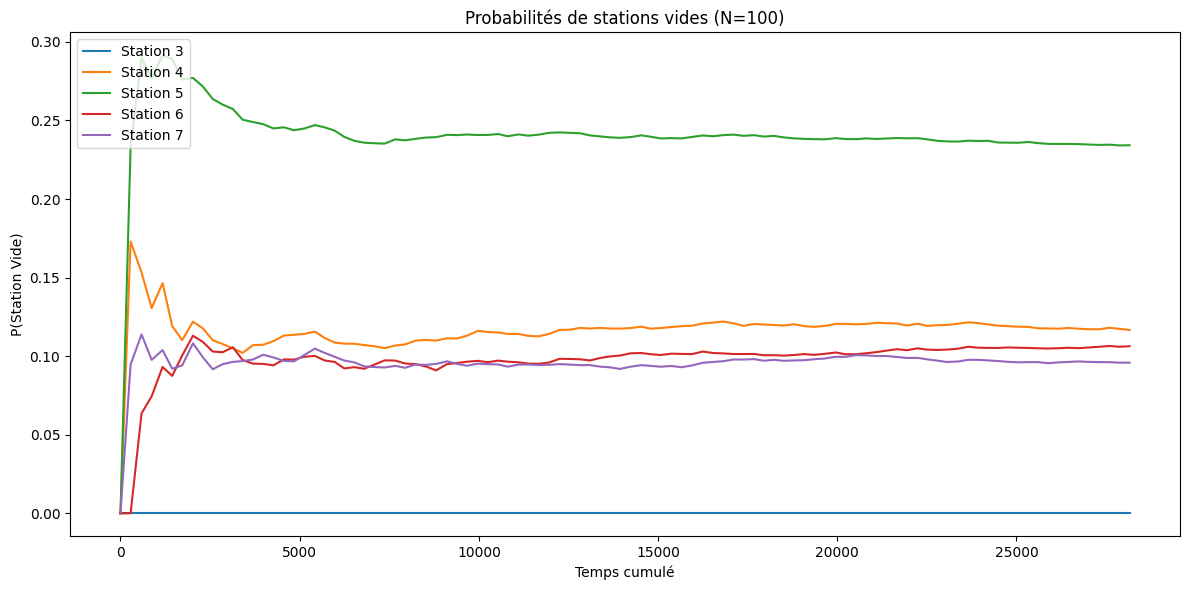

In [ ]:
N_velos = 100

#on fair ca car on a eu une erreur de division par zeros !
mu = np.zeros_like(T_heures)
mask = T_heures > 0
mu[mask] = 1.0 / T_heures[mask]


def prochain_saut(velos_stations, velos_routes):
    taux = []
    events = []

    #départs
    for i in range(M):
        if velos_stations[i] > 0:
            for k in range(M):
                if i != k:
                    rate = lambdas[i] * P[i, k]
                    taux.append(rate)
                    events.append(("depart", i, k))

    # arrivées
    for i in range(M):
        for k in range(M):
            if i != k and velos_routes[i, k] > 0:
                rate = mu[i, k] * velos_routes[i, k]
                taux.append(rate)
                events.append(("arrivee", i, k))

    taux = np.array(taux)
    Lambda = np.sum(taux) #car min d'exponentiel

    dt = np.random.exponential(1 / Lambda)

    probs = taux / Lambda
    idx = np.random.choice(len(events), p=probs) #on tire selon les proba (a/a+b+c+...)
    event = events[idx]

    return dt, event

def simulation_velib(n_sauts=1000000):
    # Initialisation avec 20 velos par station
    velos_stations = np.full(5, 20)
    velos_routes = np.zeros((M, M))

    temps_total = 0
    cumul_vide = np.zeros(M)

    historique_temps = []
    historique_vides = [[] for i in range(M)]

    for s in range(n_sauts):
        dt, event = prochain_saut(velos_stations, velos_routes)

        temps_total += dt

        for i in range(M):
            if velos_stations[i] == 0:
                cumul_vide[i] += dt

        if event[0] == "depart":
            _, i, k = event
            velos_stations[i] -= 1
            velos_routes[i, k] += 1

        else:
            _, i, k = event
            velos_routes[i, k] -= 1
            velos_stations[k] += 1

        if s % 10000 == 0:
            historique_temps.append(temps_total)
            for i in range(M):
                historique_vides[i].append(cumul_vide[i] / temps_total)

    return historique_temps, historique_vides, cumul_vide, temps_total


h_t, h_v, c_v, t_tot = simulation_velib(n_sauts=1000000)

for i in range(M):
    p_vide = (c_v[i] / t_tot)
    print(f"Station {stations_labels[i]} | Probabilité de vide : {p_vide}")

plt.figure(figsize=(12, 6))
for i in range(M):
    plt.plot(h_t, h_v[i], label=f"Station {stations_labels[i]}")

plt.title("Probabilités de stations vides (N=100)")
plt.xlabel("Temps cumulé")
plt.ylabel("P(Station Vide)")
plt.legend()
plt.tight_layout()
plt.show()